# Finite-Dimensional Gaussian Measures and Gaussian-Derived Sets

This notebook is a first, minimal example of going from a finite-dimensional `pygeoinf.GaussianMeasure` to the set it induces.

If you are new to `pygeoinf`, the core workflow is only a few steps:

1. build a Gaussian measure,
2. ask for a credible set with `credible_set(...)`,
3. sample from the measure,
4. plot the returned subset directly with `.plot()`.

The last affine-map section is optional and slightly more advanced.

## 1. Import a Small Set of Tools

We only need NumPy, Matplotlib, one SciPy function for the exact chi-squared reference probability, and `pygeoinf` itself.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

import pygeoinf as inf

np.set_printoptions(precision=4, suppress=True)
plt.style.use("default")

## 2. Build a Gaussian Measure and Ask for Its Credible Set

This is the main `pygeoinf` pattern for a new user:

1. create a `GaussianMeasure`,
2. call `credible_set(...)`,
3. work directly with the returned subset objects.

The ellipsoid and Cameron-Martin ball are two representations of the same underlying credible set.

In [2]:
space = inf.EuclideanSpace(2)
mean = np.array([0.75, -0.50])
covariance = np.array([
    [1.40, 0.60],
    [0.60, 0.90],
])

measure = inf.GaussianMeasure.from_covariance_matrix(
    space,
    covariance,
    expectation=mean,
)

probability_level = 0.90
credible_ellipsoid = measure.credible_set(probability_level, geometry="ellipsoid")
credible_ball_cm = measure.credible_set(
    probability_level,
    geometry="cameron_martin",
)


def subset_probability_from_samples(sample_array: np.ndarray, predicate) -> float:
    return float(np.mean([predicate(x) for x in sample_array]))


print(f"Gaussian mean: {mean}")
print(f"Gaussian covariance:\n{covariance}")
print(f"Credible-set radius: {credible_ellipsoid.radius:.4f}")
print(f"Returned subset types: {type(credible_ellipsoid).__name__} and {type(credible_ball_cm).__name__}")

Gaussian mean: [ 0.75 -0.5 ]
Gaussian covariance:
[[1.4 0.6]
 [0.6 0.9]]
Credible-set radius: 2.1460
Returned subset types: Ellipsoid and Ball


## 3. Draw a Few Samples

We draw reproducible samples from the `pygeoinf.GaussianMeasure`. Sampling is not required to define the credible set, but it helps build intuition for new users.

In [3]:
np.random.seed(7)
n_samples = 40_000
samples = np.array(measure.samples(n_samples))

sample_mean = samples.mean(axis=0)
sample_covariance = np.cov(samples, rowvar=False)

print("Target mean:", mean)
print("Sample mean:", sample_mean)
print()
print("Target covariance:\n", covariance)
print("Sample covariance:\n", sample_covariance)
print()
print("Mean error norm:", np.linalg.norm(sample_mean - mean))
print("Covariance error norm:", np.linalg.norm(sample_covariance - covariance))

Target mean: [ 0.75 -0.5 ]
Sample mean: [ 0.7521 -0.4971]

Target covariance:
 [[1.4 0.6]
 [0.6 0.9]]
Sample covariance:
 [[1.397  0.5996]
 [0.5996 0.8878]]

Mean error norm: 0.003646578846290779
Covariance error norm: 0.01252406047122195


## 4. Plot the Credible Set Directly

We call the subset's own `.plot()` method and then overlay samples and the mean. This is the easiest built-in `pygeoinf` plotting path for a new user.

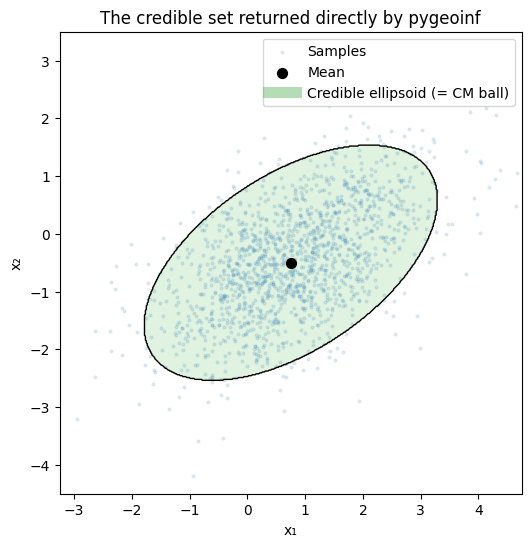

In [9]:
plot_bounds = (mean[0] - 4.0, mean[0] + 4.0, mean[1] - 4.0, mean[1] + 4.0)
fig, ax, _ = credible_ellipsoid.plot(
    bounds=plot_bounds,
    grid_size=500,
    cmap="Greens",
    alpha=0.22,
    show_plot=False,
)

ax.scatter(samples[:1500, 0], samples[:1500, 1], s=4, alpha=0.12, color="tab:blue", label="Samples")
ax.scatter(mean[0], mean[1], color="black", s=50, label="Mean")
ax.plot([], [], color="tab:green", linewidth=8, alpha=0.35, label="Credible ellipsoid (= CM ball)")

ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.set_title("The credible set returned directly by pygeoinf")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

## 5. Estimate the Gaussian Measure of the Credible Sets

We use Monte Carlo sampling to estimate the probability of the ellipsoid and Cameron-Martin representations. Since they describe the same underlying subset, the two estimates should agree up to sampling noise.

In [5]:
monte_carlo_estimates = {
    "credible_ellipsoid": subset_probability_from_samples(
        samples,
        credible_ellipsoid.is_element,
    ),
    "cameron_martin_ball": subset_probability_from_samples(
        samples,
        credible_ball_cm.is_element,
    ),
}

for name, value in monte_carlo_estimates.items():
    print(f"{name:>20s}: {value:.5f}")

same_underlying_set = all(
    credible_ellipsoid.is_element(x) == credible_ball_cm.is_element(x)
    for x in samples[:5000]
)
print()
print("Ellipsoid and Cameron-Martin ball agree on the first 5000 samples:", same_underlying_set)

  credible_ellipsoid: 0.90270
 cameron_martin_ball: 0.90270

Ellipsoid and Cameron-Martin ball agree on the first 5000 samples: True


## 6. Compare Monte Carlo with Exact Chi-Squared Calibration

For these Gaussian-derived credible sets, the reference probability is the exact chi-squared calibration used by `credible_set(...)`.

This lets us compare the empirical Monte Carlo estimates with the exact finite-dimensional target probability.

In [6]:
reference_probability = float(chi2.cdf(credible_ellipsoid.radius**2, df=space.dim))
reference_probabilities = {
    "credible_ellipsoid": reference_probability,
    "cameron_martin_ball": reference_probability,
}

print(f"{'set':>20s} | {'Monte Carlo':>12s} | {'reference':>12s} | {'abs. error':>10s}")
print("-" * 66)
for name in reference_probabilities:
    mc_value = monte_carlo_estimates[name]
    ref_value = reference_probabilities[name]
    print(f"{name:>20s} | {mc_value:12.5f} | {ref_value:12.5f} | {abs(mc_value - ref_value):10.5f}")

                 set |  Monte Carlo |    reference | abs. error
------------------------------------------------------------------
  credible_ellipsoid |      0.90270 |      0.90000 |    0.00270
 cameron_martin_ball |      0.90270 |      0.90000 |    0.00270


## 7. Optional: Affine Maps

This last section is a slightly more advanced example. It shows that when we push the Gaussian forward by an affine map, we can rebuild the corresponding credible sets for the transformed measure.

In [7]:
affine_matrix = np.array([
    [1.25, -0.45],
    [0.20, 0.95],
])
affine_shift = np.array([-0.40, 0.60])
affine_operator = inf.LinearOperator.from_matrix(space, space, affine_matrix)
transformed_measure = measure.affine_mapping(
    operator=affine_operator,
    translation=affine_shift,
)

transformed_mean = affine_matrix @ mean + affine_shift
transformed_covariance = affine_matrix @ covariance @ affine_matrix.T
transformed_samples = (affine_matrix @ samples.T).T + affine_shift

print("Transformed mean from formula:", transformed_mean)
print("Transformed mean from samples:", transformed_samples.mean(axis=0))
print()
print("Transformed covariance from formula:\n", transformed_covariance)
print("Transformed covariance from samples:\n", np.cov(transformed_samples, rowvar=False))

# The affine pushforward carries the covariance automatically. For this
# finite-dimensional demo we rebuild the measure from the transformed mean and
# covariance so that a precision operator is available for credible_set(...).
transformed_measure_with_precision = inf.GaussianMeasure.from_covariance_matrix(
    space,
    transformed_covariance,
    expectation=transformed_mean,
)

inverse_affine = np.linalg.inv(affine_matrix)


def contains_transformed_credible_image(y: np.ndarray) -> bool:
    x = inverse_affine @ (y - affine_shift)
    return credible_ellipsoid.is_element(x)


transformed_credible_ellipsoid = transformed_measure_with_precision.credible_set(
    probability_level,
    geometry="ellipsoid",
)
transformed_credible_ball_cm = transformed_measure_with_precision.credible_set(
    probability_level,
    geometry="cameron_martin",
)

original_credible_probability = subset_probability_from_samples(
    samples,
    credible_ellipsoid.is_element,
)
transformed_image_probability = subset_probability_from_samples(
    transformed_samples,
    contains_transformed_credible_image,
)
transformed_credible_probability = subset_probability_from_samples(
    transformed_samples,
    transformed_credible_ellipsoid.is_element,
)
transformed_cm_probability = subset_probability_from_samples(
    transformed_samples,
    transformed_credible_ball_cm.is_element,
)

same_transformed_set = all(
    transformed_credible_ellipsoid.is_element(y) == transformed_credible_ball_cm.is_element(y)
    for y in transformed_samples[:5000]
)

print()
print(f"P(X in original credible set)             ≈ {original_credible_probability:.5f}")
print(f"P(AX+b in affine image of credible set)   ≈ {transformed_image_probability:.5f}")
print(f"P(AX+b in transformed credible ellipsoid)≈ {transformed_credible_probability:.5f}")
print(f"P(AX+b in transformed CM ball)           ≈ {transformed_cm_probability:.5f}")
print()
print("Transformed ellipsoid and CM ball agree on the first 5000 transformed samples:", same_transformed_set)

Transformed mean from formula: [0.7625 0.275 ]
Transformed mean from samples: [0.7639 0.2782]

Transformed covariance from formula:
 [[1.6948 0.6237]
 [0.6238 1.0962]]
Transformed covariance from samples:
 [[1.688  0.6278]
 [0.6278 1.085 ]]

P(X in original credible set)             ≈ 0.90270
P(AX+b in affine image of credible set)   ≈ 0.90270
P(AX+b in transformed credible ellipsoid)≈ 0.90270
P(AX+b in transformed CM ball)           ≈ 0.90270

Transformed ellipsoid and CM ball agree on the first 5000 transformed samples: True
